In [3]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
import warnings
warnings.filterwarnings('ignore')
import re
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
import tensorflow as tf
import keras
from keras import layers
from keras.applications import efficientnet
from tensorflow.keras.utils import to_categorical, plot_model
from keras.layers import TextVectorization
from keras.preprocessing.image import load_img, img_to_array
from sklearn.model_selection import train_test_split
from nltk.translate.bleu_score import corpus_bleu
from tqdm import tqdm_notebook
from collections import Counter

In [2]:
from tensorflow.keras.applications.resnet50 import ResNet50, preprocess_input

2025-04-28 01:24:27.539411: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1745803467.735056      31 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1745803467.790536      31 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [4]:
# Path to the images
IMAGES_PATH = "/kaggle/input/flickr8k/Images"
# Path to the captions
CAPTIONS_PATH = "/kaggle/input/flickr8k/captions.txt"

# Desired image dimensions
IMAGE_SIZE = (299, 299)

# Fixed length allowed for any sequence
SEQ_LENGTH = 25

# Vocabulary size
VOCAB_SIZE = 10000

# Dimension for the image embeddings and token embeddings
EMBED_DIM = 512

# Per-layer units in the feed-forward network
FF_DIM = 512

# Batch size
BATCH_SIZE = 32

# Number of epochs
EPOCHS = 30

In [5]:
# Loads captions (text) data and maps them to corresponding images.
def load_captions_data(filename):
    with open(filename) as caption_file:
        caption_data = caption_file.readlines()[1:]
        caption_mapping = {}
        text_data = []
        images_to_skip = set()

        for line in caption_data:
            line = line.rstrip("\n")
            # Each image is repeated five times for the five different captions.
            # Image name and captions are separated using a comma
            img_name, caption = line.split(",", 1)
            img_name = os.path.join(IMAGES_PATH, img_name.strip())
            # Removing caption that are either too short to too long
            tokens = caption.strip().split()
            if len(tokens) < 5 or len(tokens) > SEQ_LENGTH:
                images_to_skip.add(img_name)
                continue

            if img_name.endswith("jpg") and img_name not in images_to_skip:
                # A start and an end token must be added to each caption
                caption = "<start> " + caption.strip() + " <end>"
                text_data.append(caption)

                if img_name in caption_mapping:
                    caption_mapping[img_name].append(caption)
                else:
                    caption_mapping[img_name] = [caption]

        for img_name in images_to_skip:
            if img_name in caption_mapping:
                del caption_mapping[img_name]

        return caption_mapping, text_data

# Splits the dataset into training, validation, and test sets
def train_val_split(caption_data, validation_size=0.2, test_size=0.05):
    all_images = list(caption_data.keys())
    # 2. First split off the test set
    train_val_ids, test_ids = train_test_split(
        all_images,
        test_size=test_size,
        random_state=42,    # ← fixes the randomness
        shuffle=True
    )

    # 3. Then split the remainder into train and validation
    #    We want validation_size of the *original* dataset,
    #    which is validation_size/(1-test_size) of train_val_ids
    val_ratio = validation_size / (1.0 - test_size)
    train_ids, val_ids = train_test_split(
        train_val_ids,
        test_size=val_ratio,
        random_state=42,
        shuffle=True
    )

    # 4. Build the dicts
    train_data = {k: caption_data[k] for k in train_ids}
    val_data   = {k: caption_data[k] for k in val_ids}
    test_data  = {k: caption_data[k] for k in test_ids}

    return train_data, val_data, test_data

# Loading the dataset
captions_mapping, text_data = load_captions_data(CAPTIONS_PATH)

# Spliting the dataset
train_data, validation_data, test_data = train_val_split(captions_mapping)
print(f"Total number of samples: {len(captions_mapping)}")
print(f"----> Number of training samples: {len(train_data)}")
print(f"----> Number of validation samples: {len(validation_data)}")
print(f"----> Number of test samples: {len(test_data)}")

Total number of samples: 7643
----> Number of training samples: 5731
----> Number of validation samples: 1529
----> Number of test samples: 383


In [6]:
# get the list of keys for each split
train_keys = list(train_data.keys())
val_keys   = list(validation_data.keys())
test_keys  = list(test_data.keys())

# take the very first one
first_train_img = train_keys[0]
first_val_img   = val_keys[0]
first_test_img  = test_keys[0]

In [11]:
import pickle

# save
with open("train_keys.pkl", "wb") as f:
    pickle.dump(train_keys, f)
    
with open("val_keys.pkl", "wb") as f:
    pickle.dump(val_keys, f)

with open("test_keys.pkl", "wb") as f:
    pickle.dump(test_keys, f)

In [8]:
first_val_img

'/kaggle/input/flickr8k/Images/2781296531_f6f0f6c0f5.jpg'

In [9]:
first_test_img

'/kaggle/input/flickr8k/Images/820169182_f5e78d7d19.jpg'

In [8]:
def custom_standardization(input_string):
    # Lowercasing all of the captions
    lowercase = tf.strings.lower(input_string)
    # Charecters to remove
    strip_chars = "!\"#$%&'()*+,-./:;=?@[\]^_`{|}~1234567890"
    return tf.strings.regex_replace(lowercase, "[%s]" % re.escape(strip_chars), "")

# Defining the vectorizer
vectorization = TextVectorization(
    max_tokens=5000,
    output_mode="int",
    output_sequence_length=40,
    standardize=custom_standardization
)

# Adapting the vectorizer with the captions
vectorization.adapt(text_data)

# Data augmentation for image data
image_augmentation = keras.Sequential([layers.RandomFlip("horizontal"),
                                       layers.RandomRotation(0.2),
                                       layers.RandomContrast(0.3)])

# Standardizing the text data
text_data = list(map(lambda x: str(custom_standardization(x).numpy())[2:-1], text_data))

I0000 00:00:1745799888.502032      31 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1745799888.502709      31 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [9]:
# Processes the images
def decode_and_resize(img_path):
    img = tf.io.read_file(img_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, IMAGE_SIZE)
    img = tf.image.convert_image_dtype(img, tf.float32)
    return img


def process_input(img_path, captions):
    # Processed images: (None, 299, 299, 3), Vectorized captions: (None, None, 25)
    return decode_and_resize(img_path), vectorization(captions)

def make_dataset(images, captions):
    ds = tf.data.Dataset.from_tensor_slices((images, captions))
    ds = ds.shuffle(BATCH_SIZE * 8)
    ds = ds.map(process_input, tf.data.AUTOTUNE)
    ds = ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return ds

train_dataset = make_dataset(list(train_data.keys()), list(train_data.values()))
validation_dataset = make_dataset(list(validation_data.keys()), list(validation_data.values()))

In [10]:
def get_cnn_model():
    base_model = ResNet50(
        input_shape=(*IMAGE_SIZE, 3),
        include_top=False,       # no final Dense
        weights="imagenet"
    )
    # Freezing the model's weights
    base_model.trainable = False
    base_model_out = base_model.output
    base_model_out = layers.Reshape((-1, base_model_out.shape[-1]))(base_model_out)
    cnn_model = keras.models.Model(base_model.input, base_model_out)
    return cnn_model

In [11]:
class TransformerEncoderBlock(layers.Layer):
    def __init__(self, embed_dim, dense_dim, num_heads, **kwargs):
        super().__init__(**kwargs)
        self.embed_dim = embed_dim
        self.dense_dim = dense_dim
        self.num_heads = num_heads
        self.attention_1 = layers.MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim, dropout=0.0)
        self.layernorm_1 = layers.LayerNormalization()
        self.layernorm_2 = layers.LayerNormalization()
        self.dense_1 = layers.Dense(embed_dim, activation="relu")

    def call(self, inputs, training, mask=None):
        inputs = self.layernorm_1(inputs)
        inputs = self.dense_1(inputs)
        attention_output_1 = self.attention_1(query=inputs,
                                              value=inputs,
                                              key=inputs,
                                              attention_mask=None,
                                              training=training)
        out_1 = self.layernorm_2(inputs + attention_output_1)
        return out_1


In [12]:
class PositionalEmbedding(layers.Layer):
    def __init__(self, sequence_length, vocab_size, embed_dim, **kwargs):
        super().__init__(**kwargs)
        self.token_embeddings = layers.Embedding(input_dim=vocab_size, output_dim=embed_dim)
        self.position_embeddings = layers.Embedding(input_dim=sequence_length, output_dim=embed_dim)
        self.sequence_length = sequence_length
        self.vocab_size = vocab_size
        self.embed_dim = embed_dim
        self.embed_scale = tf.math.sqrt(tf.cast(embed_dim, tf.float32))

    def call(self, inputs):
        length = tf.shape(inputs)[-1]
        positions = tf.range(start=0, limit=length, delta=1) # Positional encoding
        embedded_tokens = self.token_embeddings(inputs) # Input embedding
        embedded_tokens = embedded_tokens * self.embed_scale
        embedded_positions = self.position_embeddings(positions)
        return embedded_tokens + embedded_positions # Positional embedding

    def compute_mask(self, inputs, mask=None):
        return tf.math.not_equal(inputs, 0)


In [13]:
class TransformerDecoderBlock(layers.Layer):
    def __init__(self, embed_dim, ff_dim, num_heads, **kwargs):
        super().__init__(**kwargs)
        self.embed_dim = embed_dim
        self.ff_dim = ff_dim
        self.num_heads = num_heads
        self.attention_1 = layers.MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim, dropout=0.1)
        self.cross_attention_2 = layers.MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim, dropout=0.1)
        self.ffn_layer_1 = layers.Dense(ff_dim, activation="relu")
        self.ffn_layer_2 = layers.Dense(embed_dim)

        self.layernorm_1 = layers.LayerNormalization()
        self.layernorm_2 = layers.LayerNormalization()
        self.layernorm_3 = layers.LayerNormalization()

        self.embedding = PositionalEmbedding(embed_dim=EMBED_DIM,
                                             sequence_length=SEQ_LENGTH,
                                             vocab_size=VOCAB_SIZE,)
        self.out = layers.Dense(VOCAB_SIZE, activation="softmax")

        self.dropout_1 = layers.Dropout(0.3)
        self.dropout_2 = layers.Dropout(0.5)
        self.supports_masking = True

    def call(self, inputs, encoder_outputs, training, mask=None):
        inputs = self.embedding(inputs)
        causal_mask = self.get_causal_attention_mask(inputs)
        
        # If the mask is not None, it means that padding tokens are present in the input sequence.
        if mask is not None:
            padding_mask = tf.cast(mask[:, :, tf.newaxis], dtype=tf.int32)
            combined_mask = tf.cast(mask[:, tf.newaxis, :], dtype=tf.int32)
            # Masking both padding tokens and future tokens
            combined_mask = tf.minimum(combined_mask, causal_mask)

        attention_output_1 = self.attention_1(query=inputs,
                                              value=inputs,
                                              key=inputs,
                                              attention_mask=combined_mask,
                                              training=training)
        out_1 = self.layernorm_1(inputs + attention_output_1)
        
        # Note that the lengths of the inputs are different and cross-attention handles that.
        cross_attention_output_2 = self.cross_attention_2(query=out_1,
                                              value=encoder_outputs,
                                              key=encoder_outputs,
                                              attention_mask=padding_mask,
                                              training=training)
        out_2 = self.layernorm_2(out_1 + cross_attention_output_2)

        ffn_out = self.ffn_layer_1(out_2)
        ffn_out = self.dropout_1(ffn_out, training=training)
        ffn_out = self.ffn_layer_2(ffn_out)

        ffn_out = self.layernorm_3(ffn_out + out_2, training=training)
        ffn_out = self.dropout_2(ffn_out, training=training)
        
        preds = self.out(ffn_out)
        return preds
    
    # Masks future tokens
    def get_causal_attention_mask(self, inputs):
        input_shape = tf.shape(inputs)
        batch_size, sequence_length = input_shape[0], input_shape[1]
        i = tf.range(sequence_length)[:, tf.newaxis]
        j = tf.range(sequence_length)
        mask = tf.cast(i >= j, dtype="int32")
        mask = tf.reshape(mask, (1, input_shape[1], input_shape[1]))
        mult = tf.concat([tf.expand_dims(batch_size, -1),tf.constant([1, 1], dtype=tf.int32)],axis=0)
        return tf.tile(mask, mult)


In [14]:
class ImageCaptioningModel(keras.Model):
    def __init__(self, cnn_model, encoder, decoder, num_captions_per_image=5, image_aug=None):
        super().__init__()
        self.cnn_model = cnn_model
        self.encoder = encoder
        self.decoder = decoder
        self.loss_tracker = keras.metrics.Mean(name="loss")
        self.acc_tracker = keras.metrics.Mean(name="accuracy")
        self.num_captions_per_image = num_captions_per_image
        self.image_aug = image_aug
        
        print()
        print(f'CNN input shape: {cnn_model.input_shape}')
        print(f'CNN output shape: {cnn_model.output_shape}', end='\n'*2)
        print(f'Encoder input ---> Dense layer shape: {cnn_model.output_shape} ---> (None, {cnn_model.output_shape[1]}, {EMBED_DIM})')
        print(f'Encoder output shape: (None, {cnn_model.output_shape[1]}, {EMBED_DIM})', end='\n'*2)
        print(f'Decoder input 1 (Caption) ---> Positional Embedding shape: (None, {SEQ_LENGTH-1}) ---> (None, {SEQ_LENGTH-1}, {EMBED_DIM})')
        print(f'Decoder input 2 (Embedded image features) shape: (None, {cnn_model.output_shape[1]}, {EMBED_DIM})')
        print(f'Decoder output (MH Cross-Attention) shape: (None, {SEQ_LENGTH-1}, {EMBED_DIM})')
        print(f'Decoder prediction (Dense layer) shape: (None, {SEQ_LENGTH-1}, {VOCAB_SIZE})')
        
    
    # Calculates the loss, taking into account a mask to handle padding.
    def calculate_loss(self, y_true, y_pred, mask):
        loss = self.loss(y_true, y_pred)
        mask = tf.cast(mask, dtype=loss.dtype)
        loss *= mask
        return tf.reduce_sum(loss) / tf.reduce_sum(mask)
    
    # Calculates the accuracy, taking into account a mask to handle padding.
    def calculate_accuracy(self, y_true, y_pred, mask):
        accuracy = tf.equal(y_true, tf.argmax(y_pred, axis=2))
        accuracy = tf.math.logical_and(mask, accuracy)
        accuracy = tf.cast(accuracy, dtype=tf.float32)
        mask = tf.cast(mask, dtype=tf.float32)
        return tf.reduce_sum(accuracy) / tf.reduce_sum(mask)

    def _compute_caption_loss_and_acc(self, img_embed, batch_seq, training=True):
        encoder_out = self.encoder(img_embed, training=training)
        batch_seq_inp = batch_seq[:, :-1]
        batch_seq_true = batch_seq[:, 1:]
        # Creating a binary mask where 1 indicates a valid token, and 0 indicates padding.
        mask = tf.math.not_equal(batch_seq_true, 0)
        batch_seq_pred = self.decoder(batch_seq_inp, encoder_out, training=training, mask=mask)
        loss = self.calculate_loss(batch_seq_true, batch_seq_pred, mask)
        acc = self.calculate_accuracy(batch_seq_true, batch_seq_pred, mask)
        return loss, acc
    
    # Iterates through each caption for the given image, computes loss and accuracy, updates weights, and trackers.
    def train_step(self, batch_data):
        batch_img, batch_seq = batch_data
        batch_loss = 0
        batch_acc = 0
        
        # Applies image augmentation if image_aug is provided.
        if self.image_aug:
            batch_img = self.image_aug(batch_img)

        # 1. Get image embeddings
        img_embed = self.cnn_model(batch_img)

        # 2. Pass each of the five captions one by one to the decoder
        # along with the encoder outputs and compute the loss as well as accuracy
        # for each caption.
        for i in range(self.num_captions_per_image):
            with tf.GradientTape() as tape:
                loss, acc = self._compute_caption_loss_and_acc(img_embed, batch_seq[:, i, :], training=True)

                # 3. Update loss and accuracy
                batch_loss += loss
                batch_acc += acc

            # 4. Get the list of all the trainable weights
            train_vars = (self.encoder.trainable_variables + self.decoder.trainable_variables)

            # 5. Get the gradients
            grads = tape.gradient(loss, train_vars)

            # 6. Update the trainable weights
            self.optimizer.apply_gradients(zip(grads, train_vars))

        # 7. Update the trackers
        batch_acc /= float(self.num_captions_per_image)
        self.loss_tracker.update_state(batch_loss)
        self.acc_tracker.update_state(batch_acc)

        # 8. Return the loss and accuracy values
        return {"loss": self.loss_tracker.result(),
                "acc": self.acc_tracker.result()}
    
    # Similar to train_step but without updating weights.
    def test_step(self, batch_data):
        batch_img, batch_seq = batch_data
        batch_loss = 0
        batch_acc = 0

        # 1. Get image embeddings
        img_embed = self.cnn_model(batch_img)

        # 2. Pass each of the five captions one by one to the decoder
        # along with the encoder outputs and compute the loss as well as accuracy
        # for each caption.
        for i in range(self.num_captions_per_image):
            loss, acc = self._compute_caption_loss_and_acc(img_embed, batch_seq[:, i, :], training=False)

            # 3. Update batch loss and batch accuracy
            batch_loss += loss
            batch_acc += acc

        batch_acc /= float(self.num_captions_per_image)

        # 4. Update the trackers
        self.loss_tracker.update_state(batch_loss)
        self.acc_tracker.update_state(batch_acc)

        # 5. Return the loss and accuracy values
        return {"loss": self.loss_tracker.result(),
                "acc": self.acc_tracker.result()}

    @property
    def metrics(self):
        # We must list the metrics here so the `reset_states()` can be,
                                                  # called automatically.
        return [self.loss_tracker, self.acc_tracker]


In [15]:
cnn_model = get_cnn_model()
encoder = TransformerEncoderBlock(embed_dim=EMBED_DIM, dense_dim=FF_DIM, num_heads=2)
decoder = TransformerDecoderBlock(embed_dim=EMBED_DIM, ff_dim=FF_DIM, num_heads=3)
caption_model = ImageCaptioningModel(cnn_model=cnn_model, encoder=encoder, decoder=decoder, image_aug=None)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

CNN input shape: (None, 299, 299, 3)
CNN output shape: (None, 100, 2048)

Encoder input ---> Dense layer shape: (None, 100, 2048) ---> (None, 100, 512)
Encoder output shape: (None, 100, 512)

Decoder input 1 (Caption) ---> Positional Embedding shape: (None, 24) ---> (None, 24, 512)
Decoder input 2 (Embedded image features) shape: (None, 100, 512)
Decoder output (MH Cross-Attention) shape: (None, 24, 512)
Decoder prediction (Dense layer) shape: (None, 24, 10000)


In [16]:
# Defining the loss function
cross_entropy = keras.losses.SparseCategoricalCrossentropy(from_logits=False, reduction='none')

# EarlyStopping criteria
# Training will stop if there is no improvement in the validation loss for 3 consecutive epochs.
early_stopping = keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True)

In [17]:
# Learning Rate Scheduler for the optimizer
class LRSchedule(keras.optimizers.schedules.LearningRateSchedule):
    def __init__(self, post_warmup_learning_rate, warmup_steps):
        super().__init__()
        self.post_warmup_learning_rate = post_warmup_learning_rate
        self.warmup_steps = warmup_steps

    def __call__(self, step):
        global_step = tf.cast(step, tf.float32)
        warmup_steps = tf.cast(self.warmup_steps, tf.float32)
        warmup_progress = global_step / warmup_steps
        warmup_learning_rate = self.post_warmup_learning_rate * warmup_progress
        return tf.cond(
            global_step < warmup_steps,
            lambda: warmup_learning_rate,
            lambda: self.post_warmup_learning_rate)
    
# Creating a learning rate schedule
num_train_steps = len(train_dataset) * EPOCHS
num_warmup_steps = num_train_steps // 15
lr_schedule = LRSchedule(post_warmup_learning_rate=1e-4, warmup_steps=num_warmup_steps)

# Compiling the model
caption_model.compile(optimizer=keras.optimizers.Adam(lr_schedule), loss=cross_entropy)

In [18]:
# Training the model
history = caption_model.fit(train_dataset, epochs=EPOCHS, validation_data=validation_dataset, callbacks=[early_stopping])

Epoch 1/30


I0000 00:00:1745799961.379789      93 service.cc:148] XLA service 0x7fa814029330 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1745799961.380709      93 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1745799961.380731      93 service.cc:156]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
W0000 00:00:1745799964.378932      93 assert_op.cc:38] Ignoring Assert operator sparse_categorical_crossentropy/SparseSoftmaxCrossEntropyWithLogits/assert_equal_1/Assert/Assert
W0000 00:00:1745799964.855204      93 assert_op.cc:38] Ignoring Assert operator sparse_categorical_crossentropy_1/SparseSoftmaxCrossEntropyWithLogits/assert_equal_1/Assert/Assert
W0000 00:00:1745799965.330732      93 assert_op.cc:38] Ignoring Assert operator sparse_categorical_crossentropy_2/SparseSoftmaxCrossEntropyWithLogits/assert_equal_1/Assert/Assert
W0000 00:00:1745799965.797110      93 assert_op.cc:38] Ignoring 

179/180 ━━━━━━━━━━━━━━━━━━━━ 0s 474ms/step - acc: 0.1623 - loss: 32.8266

W0000 00:00:1745800089.410088      95 assert_op.cc:38] Ignoring Assert operator sparse_categorical_crossentropy/SparseSoftmaxCrossEntropyWithLogits/assert_equal_1/Assert/Assert
W0000 00:00:1745800089.758239      95 assert_op.cc:38] Ignoring Assert operator sparse_categorical_crossentropy_1/SparseSoftmaxCrossEntropyWithLogits/assert_equal_1/Assert/Assert
W0000 00:00:1745800090.106135      95 assert_op.cc:38] Ignoring Assert operator sparse_categorical_crossentropy_2/SparseSoftmaxCrossEntropyWithLogits/assert_equal_1/Assert/Assert
W0000 00:00:1745800090.460257      95 assert_op.cc:38] Ignoring Assert operator sparse_categorical_crossentropy_3/SparseSoftmaxCrossEntropyWithLogits/assert_equal_1/Assert/Assert
W0000 00:00:1745800090.812240      95 assert_op.cc:38] Ignoring Assert operator sparse_categorical_crossentropy_4/SparseSoftmaxCrossEntropyWithLogits/assert_equal_1/Assert/Assert


180/180 ━━━━━━━━━━━━━━━━━━━━ 0s 648ms/step - acc: 0.1628 - loss: 32.7867

W0000 00:00:1745800125.343661      92 assert_op.cc:38] Ignoring Assert operator sparse_categorical_crossentropy/SparseSoftmaxCrossEntropyWithLogits/assert_equal_1/Assert/Assert
W0000 00:00:1745800125.396100      92 assert_op.cc:38] Ignoring Assert operator sparse_categorical_crossentropy_1/SparseSoftmaxCrossEntropyWithLogits/assert_equal_1/Assert/Assert
W0000 00:00:1745800125.448099      92 assert_op.cc:38] Ignoring Assert operator sparse_categorical_crossentropy_2/SparseSoftmaxCrossEntropyWithLogits/assert_equal_1/Assert/Assert
W0000 00:00:1745800125.500833      92 assert_op.cc:38] Ignoring Assert operator sparse_categorical_crossentropy_3/SparseSoftmaxCrossEntropyWithLogits/assert_equal_1/Assert/Assert
W0000 00:00:1745800125.553531      92 assert_op.cc:38] Ignoring Assert operator sparse_categorical_crossentropy_4/SparseSoftmaxCrossEntropyWithLogits/assert_equal_1/Assert/Assert
W0000 00:00:1745800141.342192      92 assert_op.cc:38] Ignoring Assert operator sparse_categorical_crossent

180/180 ━━━━━━━━━━━━━━━━━━━━ 235s 839ms/step - acc: 0.1632 - loss: 32.7472 - val_acc: 0.3318 - val_loss: 19.0418
Epoch 2/30
180/180 ━━━━━━━━━━━━━━━━━━━━ 105s 582ms/step - acc: 0.3379 - loss: 18.5769 - val_acc: 0.3649 - val_loss: 17.0080
Epoch 3/30
180/180 ━━━━━━━━━━━━━━━━━━━━ 104s 576ms/step - acc: 0.3700 - loss: 16.5449 - val_acc: 0.3758 - val_loss: 16.1834
Epoch 4/30
180/180 ━━━━━━━━━━━━━━━━━━━━ 104s 579ms/step - acc: 0.3945 - loss: 15.2638 - val_acc: 0.3875 - val_loss: 15.6595
Epoch 5/30
180/180 ━━━━━━━━━━━━━━━━━━━━ 104s 576ms/step - acc: 0.4179 - loss: 14.3047 - val_acc: 0.3921 - val_loss: 15.4022
Epoch 6/30
180/180 ━━━━━━━━━━━━━━━━━━━━ 104s 577ms/step - acc: 0.4364 - loss: 13.5036 - val_acc: 0.3950 - val_loss: 15.3649
Epoch 7/30
180/180 ━━━━━━━━━━━━━━━━━━━━ 104s 580ms/step - acc: 0.4563 - loss: 12.7292 - val_acc: 0.3925 - val_loss: 15.3523
Epoch 8/30
180/180 ━━━━━━━━━━━━━━━━━━━━ 104s 578ms/step - acc: 0.4744 - loss: 12.0643 - val_acc: 0.3944 - val_loss: 15.5199
Epoch 9/30
180/180 

In [19]:
import numpy as np
import tensorflow as tf
from tqdm import tqdm_notebook

vocab = vectorization.get_vocabulary()
INDEX_TO_WORD = {idx: word for idx, word in enumerate(vocab)}
MAX_DECODED_SENTENCE_LENGTH = SEQ_LENGTH - 1
test_images = list(test_data.keys())

def greedy_algorithm(image_path):
    # 1) preprocess & encode image
    img = decode_and_resize(image_path)
    img = tf.expand_dims(img, 0)
    img_feats = caption_model.cnn_model(img)
    enc_out   = caption_model.encoder(img_feats, training=False)

    # 2) generate step-by-step
    decoded = "<start>"
    for i in range(MAX_DECODED_SENTENCE_LENGTH):
        tokenized = vectorization([decoded])[:, :-1]
        mask      = tf.math.not_equal(tokenized, 0)
        preds     = caption_model.decoder(tokenized, enc_out,
                                          training=False, mask=mask)
        next_id   = np.argmax(preds[0, i, :])
        next_word = INDEX_TO_WORD[next_id]
        if next_word == "<end>":
            break
        decoded += " " + next_word

    return decoded.replace("<start> ", "").replace(" <end>", "").strip()

def beam_search_algorithm(image_path, beam_width=3):
    img = decode_and_resize(image_path)
    img = tf.expand_dims(img, 0)
    img_feats = caption_model.cnn_model(img)
    enc_out   = caption_model.encoder(img_feats, training=False)

    beams = [("<start>", 0.0)]
    for _ in range(MAX_DECODED_SENTENCE_LENGTH):
        candidates = []
        for seq, score in beams:
            if seq.split()[-1] == "<end>":
                candidates.append((seq, score))
                continue
            tokenized = vectorization([seq])[:, :-1]
            mask      = tf.math.not_equal(tokenized, 0)
            preds     = caption_model.decoder(tokenized, enc_out,
                                              training=False, mask=mask)
            t = len(seq.split()) - 1
            log_probs = np.log(preds[0, t, :].numpy() + 1e-9)
            top_k     = np.argsort(log_probs)[-beam_width:]
            for idx in top_k:
                word = INDEX_TO_WORD[idx]
                cand_seq = seq + " " + word
                cand_score = score - log_probs[idx]
                candidates.append((cand_seq, cand_score))
        # keep best beams
        beams = sorted(candidates, key=lambda x: x[1])[:beam_width]
        if all(b[0].split()[-1] == "<end>" for b in beams):
            break

    best = beams[0][0]
    return best.replace("<start> ", "").replace(" <end>", "").strip()

# Generate both greedy & beam captions
generated_greedy = {}
generated_beam   = {}

pbar = tqdm_notebook(total=len(test_images), desc="Generating captions", colour='green')
for img_path in test_images:
    generated_greedy[img_path] = greedy_algorithm(img_path)
    generated_beam[img_path]   = beam_search_algorithm(img_path, beam_width=5)
    pbar.update(1)
pbar.close()

Generating captions:   0%|          | 0/383 [00:00<?, ?it/s]

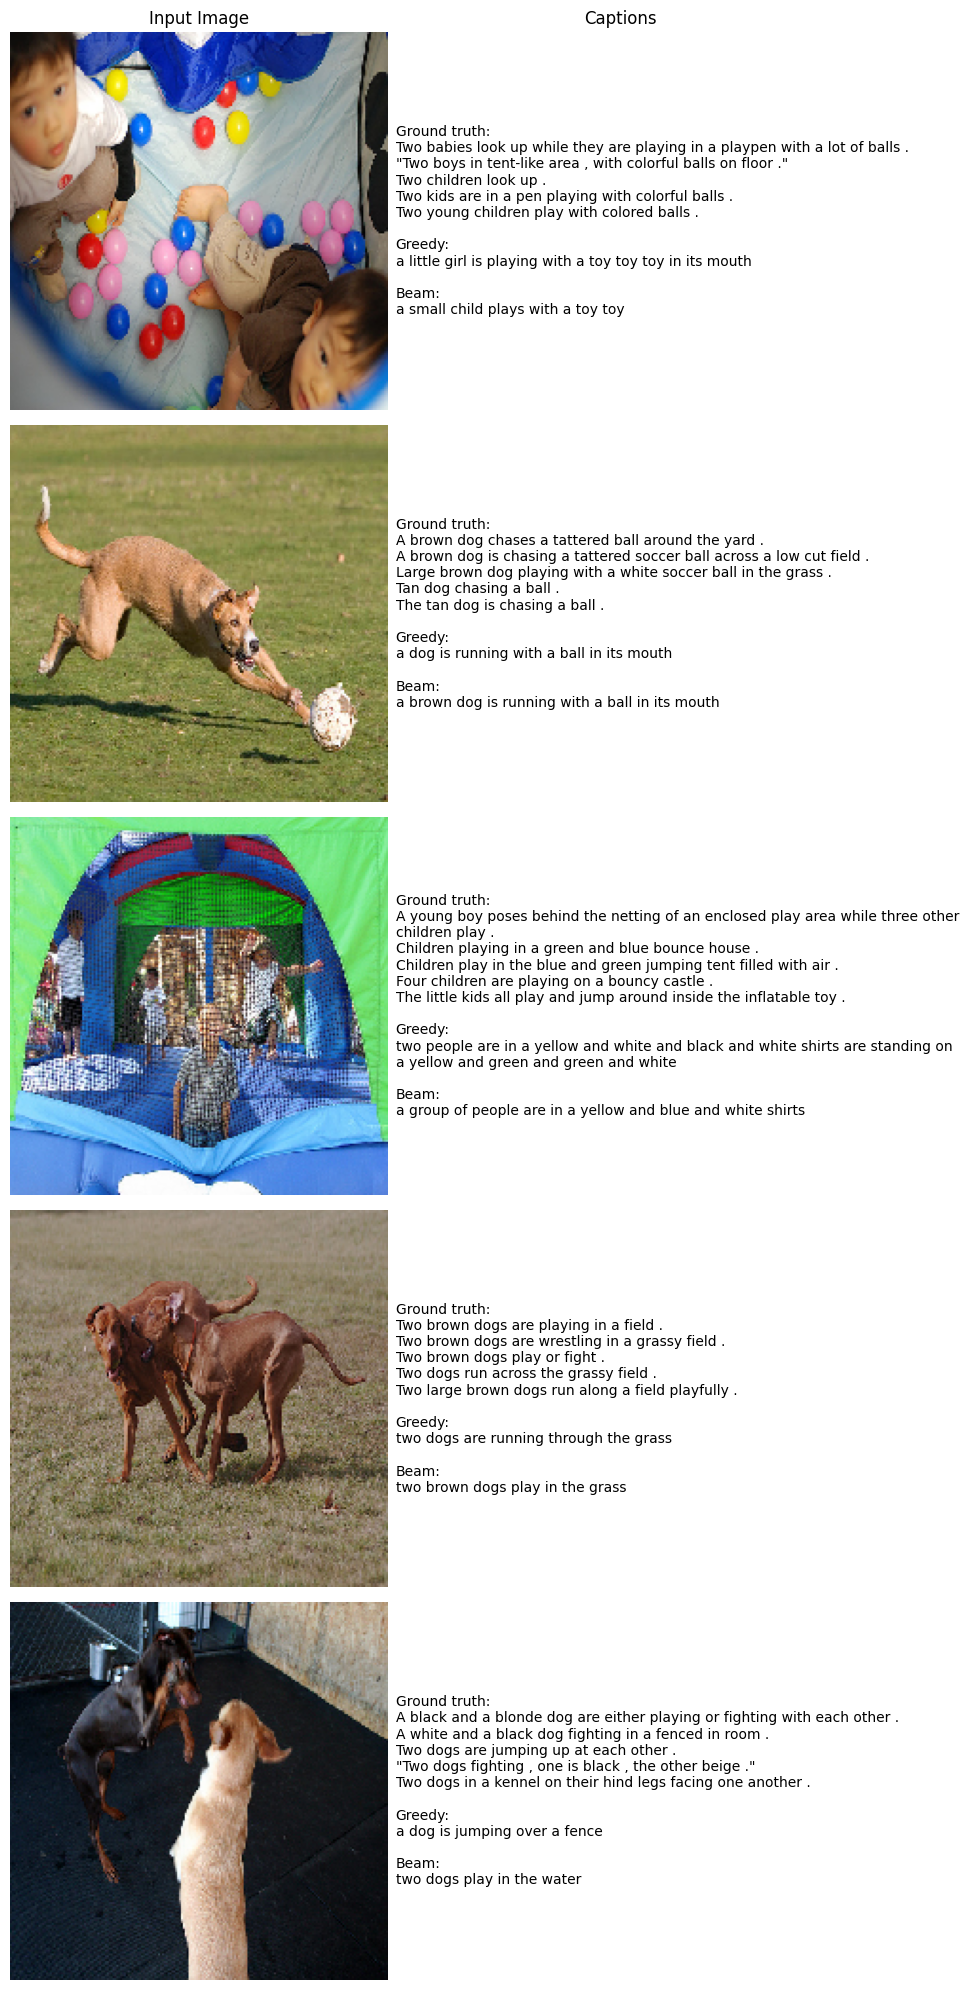

In [20]:
def show_first_n_results(data, greedy_captions, beam_captions, n=5, image_size=(199,199)):
    """
    data:             { img_path: [gt1, gt2, …] }
    greedy_captions:  { img_path: "greedy output" }
    beam_captions:    { img_path: "beam output" }
    """
    keys = list(data.keys())[:n]
    fig, axes = plt.subplots(n, 2, figsize=(10, 4*n))
    
    for i, img_path in enumerate(keys):
        # ---- image ----
        img = load_img(img_path, target_size=image_size)
        ax_img = axes[i, 0]
        ax_img.imshow(img)
        ax_img.axis('off')
        if i == 0:
            ax_img.set_title("Input Image")
        
        # ---- texts ----
        # ground truth (strip tokens)
        gt_caps = [
            c.replace("<start> ","").replace(" <end>","")
            for c in data[img_path]
        ]
        gt_text = "\n".join(gt_caps)
        
        # greedy
        greedy = greedy_captions[img_path]
        greedy = greedy.replace("<start> ","").replace(" <end>","")
        
        # beam
        beam = beam_captions[img_path]
        beam = beam.replace("<start> ","").replace(" <end>","")
        
        display = (
            f"Ground truth:\n{gt_text}\n\n"
            f"Greedy:\n{greedy}\n\n"
            f"Beam:\n{beam}"
        )
        
        ax_txt = axes[i, 1]
        ax_txt.axis('off')
        if i == 0:
            ax_txt.set_title("Captions")
        ax_txt.text(0, 0.5, display, va='center', wrap=True, fontsize=10)
    
    plt.tight_layout()
    plt.show()

# Usage:
show_first_n_results(
    test_data,
    generated_greedy,
    generated_beam,
    n=5
)


In [21]:
from nltk.translate.bleu_score import corpus_bleu

# 1) fix an ordering of your test images
test_images = list(test_data.keys())

# 2) build your reference lists
references = [
    [ cap.replace("<start> ","").replace(" <end>","").split()
      for cap in test_data[img_id] ]
    for img_id in test_images
]

# 3) build hypotheses for greedy and beam
greedy_hyps = [
    generated_greedy[img_id].replace("<start> ","")\
                             .replace(" <end>","")\
                             .split()
    for img_id in test_images
]
beam_hyps   = [
    generated_beam[img_id].replace("<start> ","")\
                           .replace(" <end>","")\
                           .split()
    for img_id in test_images
]

# 4) compute and print BLEU-1…4 for both methods
weights = {
    "BLEU-1": (1,   0,   0,   0),
    "BLEU-2": (0.5, 0.5, 0,   0),
    "BLEU-3": (1/3, 1/3, 1/3, 0),
    "BLEU-4": (0.25,0.25,0.25,0.25),
}

print("=== Greedy search BLEU scores ===")
for name, w in weights.items():
    score = corpus_bleu(references, greedy_hyps, weights=w)
    print(f"{name}: {score*100:.2f}")

print("\n=== Beam search BLEU scores ===")
for name, w in weights.items():
    score = corpus_bleu(references, beam_hyps, weights=w)
    print(f"{name}: {score*100:.2f}")

=== Greedy search BLEU scores ===
BLEU-1: 50.76
BLEU-2: 32.14
BLEU-3: 19.88
BLEU-4: 11.79

=== Beam search BLEU scores ===
BLEU-1: 52.05
BLEU-2: 33.85
BLEU-3: 22.28
BLEU-4: 14.20
